In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [27]:
upload = files.upload()

Saving hidden gem.png to hidden gem.png


array([[[ 18,  18,  18],
        [ 18,  18,  18],
        [ 18,  18,  18],
        ...,
        [ 18,  18,  18],
        [ 18,  18,  18],
        [ 18,  18,  18]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 18,  18,  18],
        [ 18,  18,  18],
        [ 18,  18,  18]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 18,  18,  18],
        [ 18,  18,  18],
        [ 18,  18,  18]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [254, 254, 254],
        ...,
        [ 18,  18,  18],
        [ 18,  18,  18],
        [ 18,  18,  18]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 18,  18,  18],
        [ 18,  18,  18],
        [ 18,  18,  18]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 18,  18,  18],
        [ 18,  18,  18],
        [ 18,  18,  18]]], dtype=uint8)
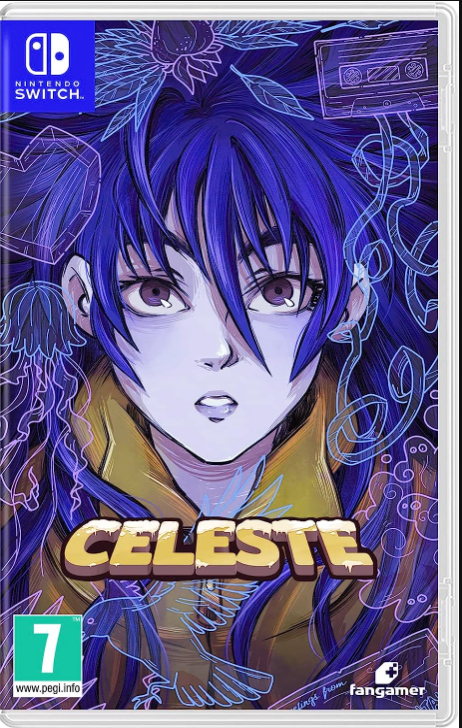

In [28]:
img = cv2.imread('hidden gem.png')
img

array([[ 18,  18,  18, ...,  18,  18,  18],
       [255, 255, 255, ...,  18,  18,  18],
       [255, 255, 255, ...,  18,  18,  18],
       ...,
       [255, 255, 254, ...,  18,  18,  18],
       [255, 255, 255, ...,  18,  18,  18],
       [255, 255, 255, ...,  18,  18,  18]], dtype=uint8)
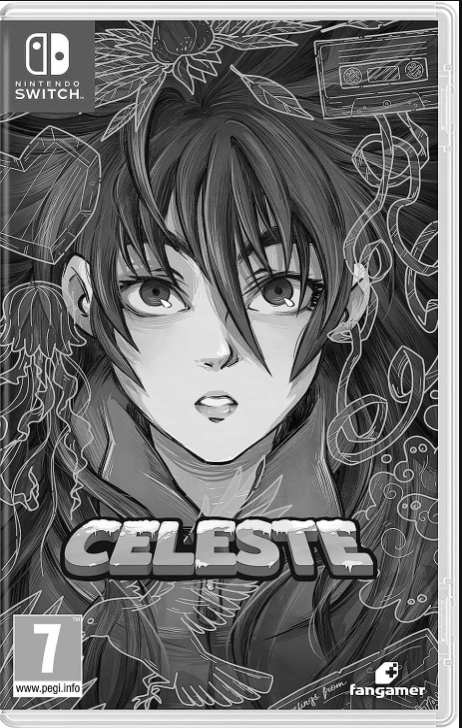

In [29]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_gray

In [30]:
def quantizar(img, bits):
  niveis = 2**bits
  passo = 256/niveis
  quantizada = (img/passo).astype(np.uint8)
  if niveis > 1:
    quantizada = np.round(quantizada*(255/(niveis-1))).astype(np.uint8)
  return quantizada

img_1bit = quantizar(img_gray, 1)
img_2bit = quantizar(img_gray, 2)
img_4bit = quantizar(img_gray, 4)
img_8bit = quantizar(img_gray, 8)

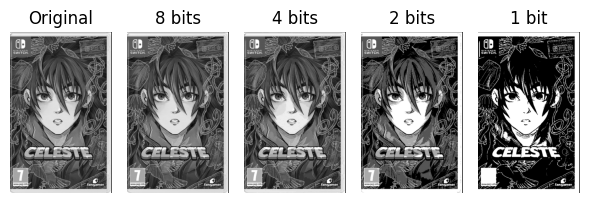

In [40]:
fig, ax = plt.subplots(1, 5, figsize=(6,4))

ax[0].imshow(img_gray, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(img_8bit, cmap='gray')
ax[1].set_title('8 bits')
ax[1].axis('off')

ax[2].imshow(img_4bit, cmap='gray')
ax[2].set_title('4 bits')
ax[2].axis('off')

ax[3].imshow(img_2bit, cmap='gray')
ax[3].set_title('2 bits')
ax[3].axis('off')

ax[4].imshow(img_1bit, cmap='gray')
ax[4].set_title('1 bit')
ax[4].axis('off')

plt.tight_layout()
plt.savefig('quantizacao.png')
plt.show()

Para números de bits menores, devido ao menor número de tons disponíveis, os detalhes da imagem se tornam menos visíveis, enquanto as transições de intensidade ficam mais aparentes.